# 06 - Evaluation

The selected model fit on the full training set and examined on the held-out sessions: headline metrics, residual behaviour, and a per-session breakdown to see whether the error is spread evenly or concentrated in particular runs.

In [1]:
import sys
sys.path.append("..")

import pandas as pd
from src.data_prep import load_raw, clean, split_by_profile
from src.model import build_model
from src.evaluate import regression_metrics, per_session_rmse, plot_diagnostics
from src.config import GROUP_COL

df = clean(load_raw())
X_train, X_test, y_train, y_test, groups_train = split_by_profile(df)
test_sessions = df.iloc[X_test.index][GROUP_COL].values

model = build_model().fit(X_train, y_train)
pred = model.predict(X_test)
regression_metrics(y_test, pred)

{'rmse': 10.842698157061415,
 'mae': 8.452491162949535,
 'r2': 0.6708535213279592}

Test RMSE around 10.8 C and R2 about 0.67 on motor runs the model never saw. As a sanity check on bias, the residuals average close to zero, so the model isn't systematically over or under predicting overall.

## Residual diagnostics

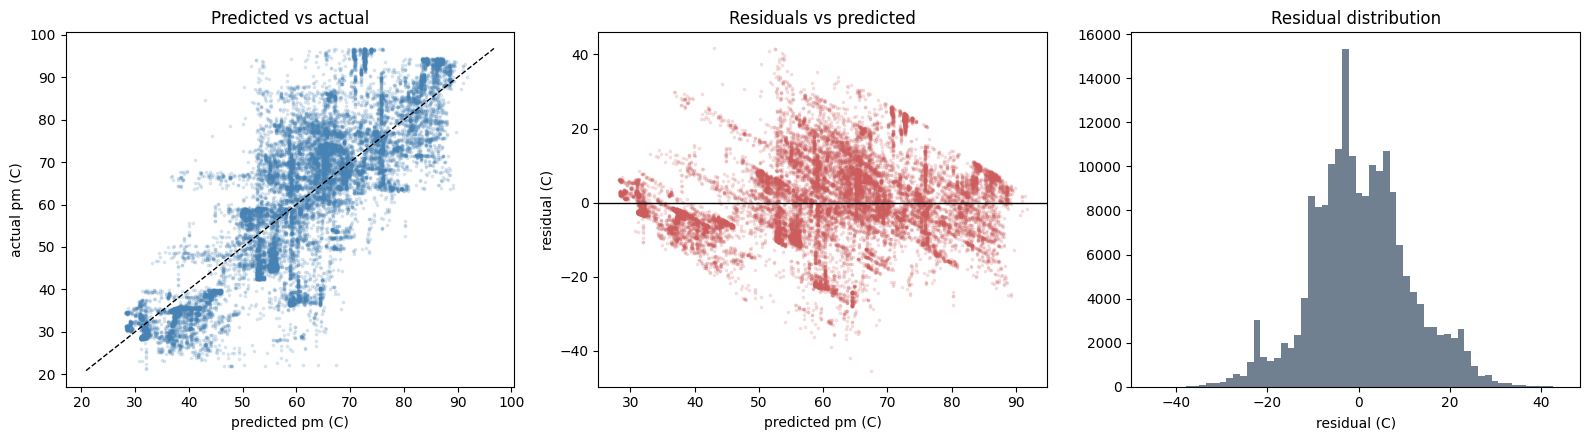

In [2]:
fig = plot_diagnostics(y_test, pred, save_path="../reports/figures/residual_diagnostics.png")

Predicted against actual sits along the diagonal across most of the range, with the spread widening at the hot end where the model tends to fall a little short of the highest magnet temperatures. The residuals are roughly centred and symmetric, but their spread is wide, which matches the per-session story below: the model is accurate on most runs and off on a few, and those few stretch the residual tails.

## Error by held-out session

g
7.0      5.27
5.0      5.59
50.0     6.98
68.0     9.23
74.0     9.62
21.0     9.78
15.0    11.14
73.0    11.22
80.0    11.71
14.0    13.97
19.0    19.88
dtype: float64

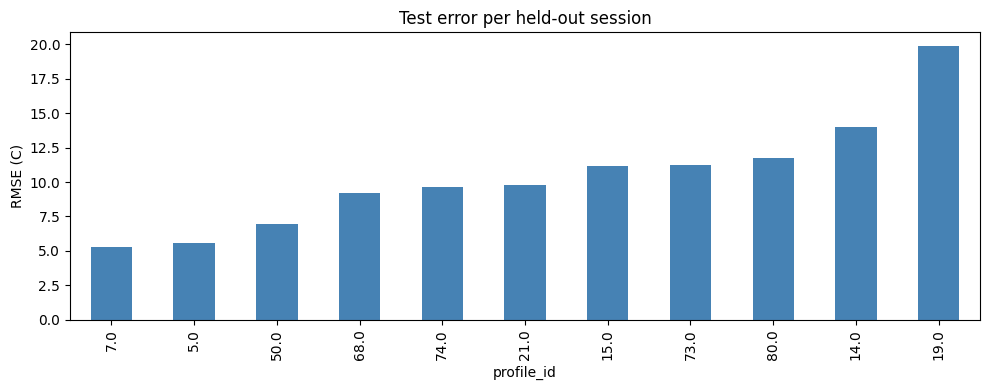

In [3]:
session_rmse = per_session_rmse(y_test, pred, test_sessions)

ax = session_rmse.plot.bar(figsize=(10, 4), color="steelblue")
ax.set_xlabel("profile_id")
ax.set_ylabel("RMSE (C)")
ax.set_title("Test error per held-out session")
ax.figure.tight_layout()
ax.figure.savefig("../reports/figures/session_rmse.png", dpi=120, bbox_inches="tight")
session_rmse.round(2)

This is the most informative view. The aggregate RMSE hides a wide range across sessions, from about 5 C on the easiest runs to roughly 20 C on the worst, where the worst case is no better than predicting the mean. So the model isn't uniformly good, it generalises well to runs that resemble the training data and breaks down on operating regimes it hasn't really seen. With only 54 sessions in total, a couple of unusual held-out runs move the headline number a lot.

The practical reading: I'd quote the test RMSE with this spread attached rather than on its own, and if this were going into production the obvious next steps are more recorded sessions to cover more regimes, or features that capture the thermal history within a run rather than treating each timestep independently.

## Worst case and the dangerous direction

RMSE and MAE describe the typical error, but a thermal-protection use case cares about the *worst* miss and about which direction it goes. Under-predicting, calling the magnet cooler than it actually is, is the risky failure: it's the case where a protection system would fail to derate a motor that is genuinely too hot. So alongside the averages I look at the maximum error and the size of the under-prediction tail. A production version optimising for safety would go further and train an asymmetric loss that penalises under-prediction harder than over-prediction.

In [4]:
import numpy as np
from sklearn.metrics import max_error

# signed error, negative means the model called the magnet colder than it was
err = pred - np.asarray(y_test)

print(f"max absolute error:        {max_error(y_test, pred):.1f} C")
print(f"worst under-prediction:    {-err.min():.1f} C  (said colder than truth)")
print(f"worst over-prediction:     {err.max():.1f} C")

# for thermal protection the under-predictions are the tail that matters:
# reading the magnet as cooler than it is means failing to derate a hot motor
for thr in (5, 10, 15):
    share = (err < -thr).mean() * 100
    print(f"under-predicted by > {thr:>2} C:   {share:5.2f}% of rows")

# worst single miss within each held-out session
worst_by_session = (pd.Series(np.abs(err), index=test_sessions)
                    .groupby(level=0).max().sort_values())
worst_by_session.round(1)

max absolute error:        45.3 C
worst under-prediction:    44.0 C  (said colder than truth)
worst over-prediction:     45.3 C
under-predicted by >  5 C:   32.34% of rows
under-predicted by > 10 C:   17.00% of rows
under-predicted by > 15 C:    9.64% of rows


7.0     25.5
14.0    28.2
5.0     32.6
74.0    35.1
73.0    36.0
50.0    39.4
80.0    40.5
19.0    40.6
21.0    42.5
68.0    44.0
15.0    45.3
dtype: float64

## Summary table

Final model against the references, on the held-out sessions.

In [5]:
summary = pd.DataFrame([
    {"model": "mean baseline", "test_rmse": 19.57, "test_mae": 16.93, "test_r2": -0.07},
    {"model": "linear regression", "test_rmse": 11.74, "test_mae": 9.20, "test_r2": 0.61},
    {"model": "random forest", "test_rmse": 13.21, "test_mae": 10.36, "test_r2": 0.51},
    {"model": "gradient boosting (tuned)", "test_rmse": round(regression_metrics(y_test, pred)["rmse"], 2),
     "test_mae": round(regression_metrics(y_test, pred)["mae"], 2),
     "test_r2": round(regression_metrics(y_test, pred)["r2"], 2)},
]).set_index("model")
summary

,test_rmse,test_mae,test_r2
model,,,
mean baseline,19.57,16.93,-0.07
linear regression,11.74,9.20,0.61
random forest,13.21,10.36,0.51
gradient boosting (tuned),10.84,8.45,0.67
